# 02회 - 배송 소요 시간 예측

#### Q01. 라이브러리 임포트

In [200]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02. 데이터 불러오기

In [201]:
delivery_df = pd.read_csv('../datasets/delivery_time.csv')

#### Q03.  데이터 확인

In [202]:
#delivery_df.dropna(inplace=True)
#delivery_df.isnull().sum()

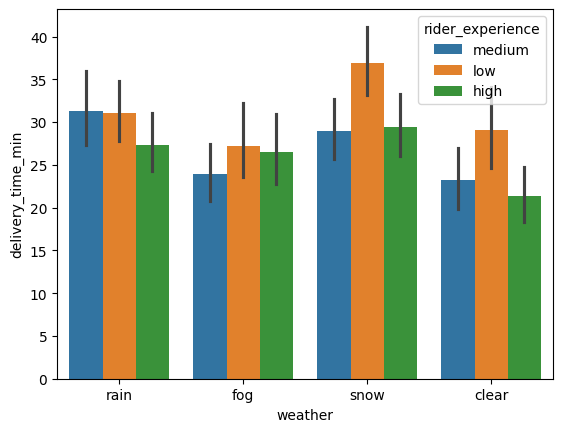

In [203]:
sns.barplot(data=delivery_df, x="weather", y="delivery_time_min", hue='rider_experience')
답03 = 1

#### Q04. 데이터 시각화에 따른 이상치 제거

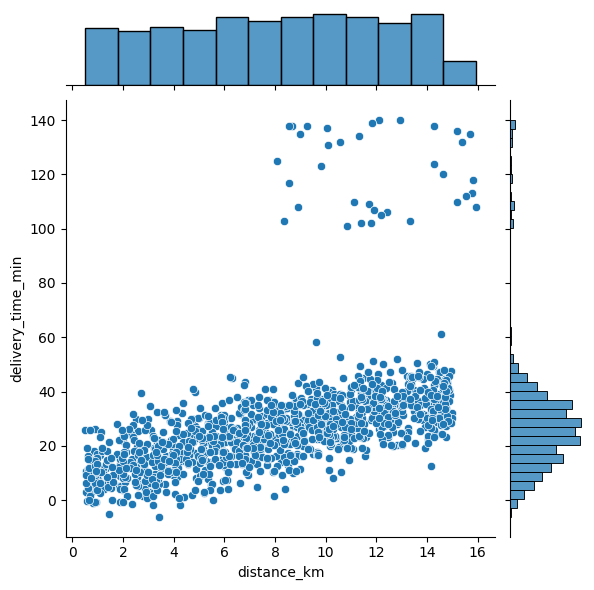

In [204]:
sns.jointplot(data=delivery_df, x="distance_km", y="delivery_time_min")

del_df = delivery_df.drop(delivery_df[delivery_df['delivery_time_min']>=100].index, axis=0)

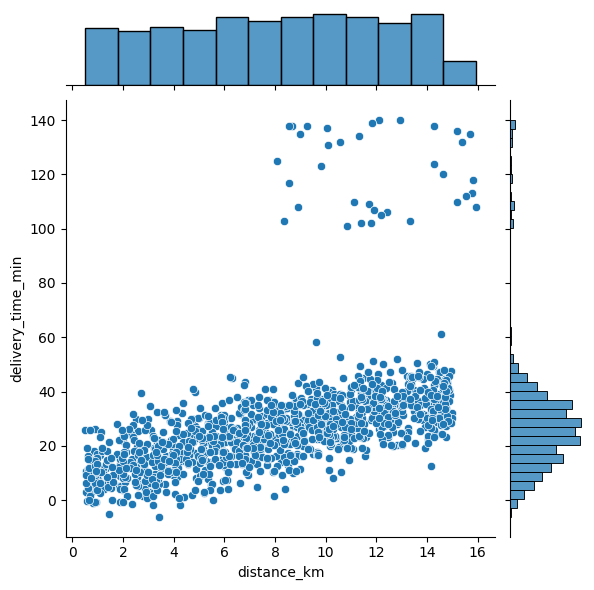

In [205]:
sns.jointplot(data=delivery_df, x="distance_km", y="delivery_time_min")

#### Q05. 이상치 제거 및 인덱스 초기화

In [206]:
len(del_df[del_df['delivery_time_min'] < 0].index)

11

In [207]:
del_df.drop(del_df[del_df['delivery_time_min'] < 0].index, axis=0, inplace=True)
del_df.reset_index(drop=True, inplace=True)

In [208]:
len(del_df[del_df['delivery_time_min'] < 0].index)

0

#### Q06. 필요없는 컬럼 제거

In [209]:
# del_df.drop(columns=['order_amount', 'num_items'], inplace=True)
del_df.drop(['order_amount', 'num_items'], axis=1, inplace=True)
del_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distance_km        1153 non-null   float64
 1   rider_experience   1153 non-null   str    
 2   weather            1153 non-null   str    
 3   order_time         1153 non-null   str    
 4   promotion_applied  1153 non-null   str    
 5   delivery_time_min  1153 non-null   float64
dtypes: float64(2), str(4)
memory usage: 54.2 KB


#### Q07. 범주형 변수 인코딩

In [210]:
cat_col = ['rider_experience', 'weather', 'order_time'] 

In [211]:
encoding_df = pd.get_dummies(data=del_df, columns=cat_col, drop_first=True)
encoding_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              1153 non-null   float64
 1   promotion_applied        1153 non-null   str    
 2   delivery_time_min        1153 non-null   float64
 3   rider_experience_low     1153 non-null   bool   
 4   rider_experience_medium  1153 non-null   bool   
 5   weather_fog              1153 non-null   bool   
 6   weather_rain             1153 non-null   bool   
 7   weather_snow             1153 non-null   bool   
 8   order_time_evening       1153 non-null   bool   
 9   order_time_morning       1153 non-null   bool   
 10  order_time_night         1153 non-null   bool   
dtypes: bool(8), float64(2), str(1)
memory usage: 36.2 KB


#### Q08. 이진 범주형 변수 인코딩

In [212]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [213]:
encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])
encoding_df['promotion_applied']

0       0
1       0
2       1
3       0
4       1
       ..
1148    0
1149    1
1150    0
1151    1
1152    1
Name: promotion_applied, Length: 1153, dtype: int64

#### Q09. train/test 데이터 분리

In [214]:
X = encoding_df.drop(columns='delivery_time_min')
y = encoding_df['delivery_time_min']

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

#### Q10. 데이터 표준화

In [215]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_valid)

#### Q11. 선형 회귀 모델 학습

In [216]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Q12. 랜덤포레스트 회귀모델 학습

In [217]:
from sklearn.ensemble import RandomForestRegressor

In [218]:
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Q13. 딥러닝 모델 설계 및 학습

In [219]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

tf.random.set_seed(42)

In [220]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear')) 

model.compile(optimizer='adam',
              loss='mean_squared_error', 
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, epochs=50, batch_size=128,
          validation_data=(X_valid, y_valid))

d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 695.7317 - mean_absolute_error: 23.9872 - val_loss: 700.0463 - val_mean_absolute_error: 24.1167
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 662.7531 - mean_absolute_error: 23.4222 - val_loss: 649.7056 - val_mean_absolute_error: 23.1764
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 632.4473 - mean_absolute_error: 22.8940 - val_loss: 590.0616 - val_mean_absolute_error: 22.0054
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 602.8082 - mean_absolute_error: 22.3691 - val_loss: 519.6013 - val_mean_absolute_error: 20.5427
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 573.5560 - mean_absolute_error: 21.8406 - val_loss: 441.3206 - val_mean_absolute_error: 18.7955
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 544.1850 - mean_absolute_error: 21.2999 - val_loss: 357.2933 - val_mean_absolute_error: 16.7371
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 514.2602 - mean_absolute_

#### Q14. 모델 EarlyStopping, 체크포인트 저장

In [221]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
early_stopping = EarlyStopping(
	monitor='val_loss',
	patience=5,
    restore_best_weights=True   
)

model_checkpoint = ModelCheckpoint(
	filepath='best_model.h5',
	monitor='val_loss',
	save_best_only=True,
	verbose=1
)

model.fit(
	X_train, y_train,
	epochs=50,
	validation_data=(X_valid, y_valid),
	callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 43.3758 - mean_absolute_error: 5.3294
Epoch 1: val_loss improved from None to 2489.21655, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 39.7674 - mean_absolute_error: 5.0712 - val_loss: 2489.2166 - val_mean_absolute_error: 48.1555
Epoch 2/50
23/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42.9656 - mean_absolute_error: 5.2996
Epoch 2: val_loss did not improve from 2489.21655
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38.7767 - mean_absolute_error: 5.0009 - val_loss: 2509.2849 - val_mean_absolute_error: 48.3772
Epoch 3/50
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41.3196 - mean_absolute_error: 5.1876
Epoch 3: val_loss did not improve from 2489.21655
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 37.9365 - mean_absolute_error: 4.9451 - val_loss: 2559.7686 - val_mean_absolute_error: 48.8812
Epoch 4/50
24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.6989 - mean_absolute_error: 5.1474
Epoch 4: val_loss did not improve from 2489.21655
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 36.9925 - mean_absolute_error: 4.8778